In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
from astropy.stats import sigma_clip
from scipy.optimize import curve_fit

from ztf_snia_sim_params import SIM_PARAMS

In [5]:
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]

In [6]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [7]:
data.columns

Index(['Unnamed: 0', 'ztfname', 'redshift', 'redshift_err', 'source', 't0',
       'x0', 'x1', 'c', 't0_err', 'x0_err', 'x1_err', 'c_err', 'cov_t0_x0',
       'cov_t0_x1', 'cov_t0_c', 'cov_x0_x1', 'cov_x0_c', 'cov_x1_c', 'mwebv',
       'mwr_v', 'mwebv_err', 'fitprob', 'ra', 'dec', 'sn_type', 'sub_type',
       'lccoverage_flag', 'fitquality_flag', 'iau_name', 'frac_fitted',
       'ra_host', 'dec_host', 'mass', 'mass_err', 'restframe_gz',
       'restframe_gz_err', 'd_dlr'],
      dtype='object')

[  2.24500767 -19.11347805   0.16821636]


Text(0, 0.5, 'Density')

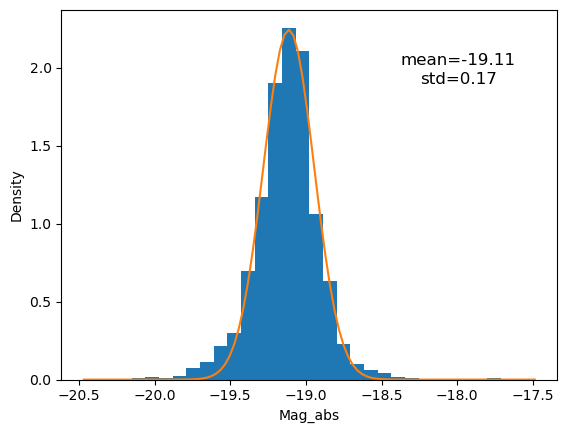

In [8]:
alpha = ALPHA
beta = BETA

good_idx = (data.fitquality_flag ==1) & (data.lccoverage_flag ==1) &\
           (~data.x0.isna()) & (data.sn_type != 'snia-pec')
mag = -2.5*np.log10(data[good_idx].x0) + 10.635
cosmo = FlatLambdaCDM(H0=H0, Om0=OMEGA_M)
mu = cosmo.distmod(data[good_idx].redshift)
mag_abs = mag - mu.value + alpha*data[good_idx].x1 - beta*data[good_idx].c
ax = plt.subplot()
counts, bins, _ = ax.hist(mag_abs,bins=30,density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[max(counts), np.mean(mag_abs), np.std(mag_abs)])
print(popt)
A, mean, std = popt
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
y = gaussian(x, A, mean, std)
ax.plot(x, y)
plt.text(0.8, 0.85, f'mean={mean:.2f}', fontsize=12, color='k',transform=ax.transAxes,horizontalalignment='center')
plt.text(0.8, 0.8, f'std={std:.2f}', fontsize=12, color='k',transform=ax.transAxes,horizontalalignment='center')
plt.xlabel("Mag_abs")
plt.ylabel("Density")